# Assignment

## Brief

Write the Python codes for the following questions.

## Instructions

Paste the answer as Python in the answer code section below each question.

### Question 1

Question: Implement a simple Thrift server and client that defines a `Student` struct with fields `name` (string), `age` (integer), and `courses` (list of strings). Include a service `School` with a method `enrollCourse` that takes a `Student` record and a course name, adds the course to the student's course list, and returns the updated `Student` record.

Answer:

In [30]:
%%writefile ../schema/student.thrift

struct Student {
  1: required string name,
  2: optional i32 age,
  3: required list<string> courses
}

service School {
  Student enrollCourse(1: required Student student, 2: required string course)
}


Overwriting ../schema/student.thrift


In [31]:
%%writefile ../student_thrift_server.py
import thriftpy2
from thriftpy2.rpc import make_server

student_thrift = thriftpy2.load("./schema/student.thrift", module_name="student_thrift")

class School(object):
    def enrollCourse(self, student, course):
        student.courses.append(course)
        return student

server = make_server(student_thrift.School, School(), client_timeout=None)
print("Starting and running the server on default host and port...")
print("Press Ctrl+C to stop the server.")
server.serve()


Overwriting ../student_thrift_server.py


In [32]:
%%writefile ../student_thrift_client.py
import thriftpy2
from thriftpy2.rpc import make_client

student_thrift = thriftpy2.load("./schema/student.thrift", module_name="student_thrift")

client = make_client(student_thrift.School)
student = student_thrift.Student(name="Alice", age=20, courses=["Math"])
print("Original student:", student)

updated_student = client.enrollCourse(student, "Physics")
print("Updated student:", updated_student)
client.close()


Overwriting ../student_thrift_client.py


Executing the created student_thrift_server.py and student_thrift_client.py, in previous 2 cells.

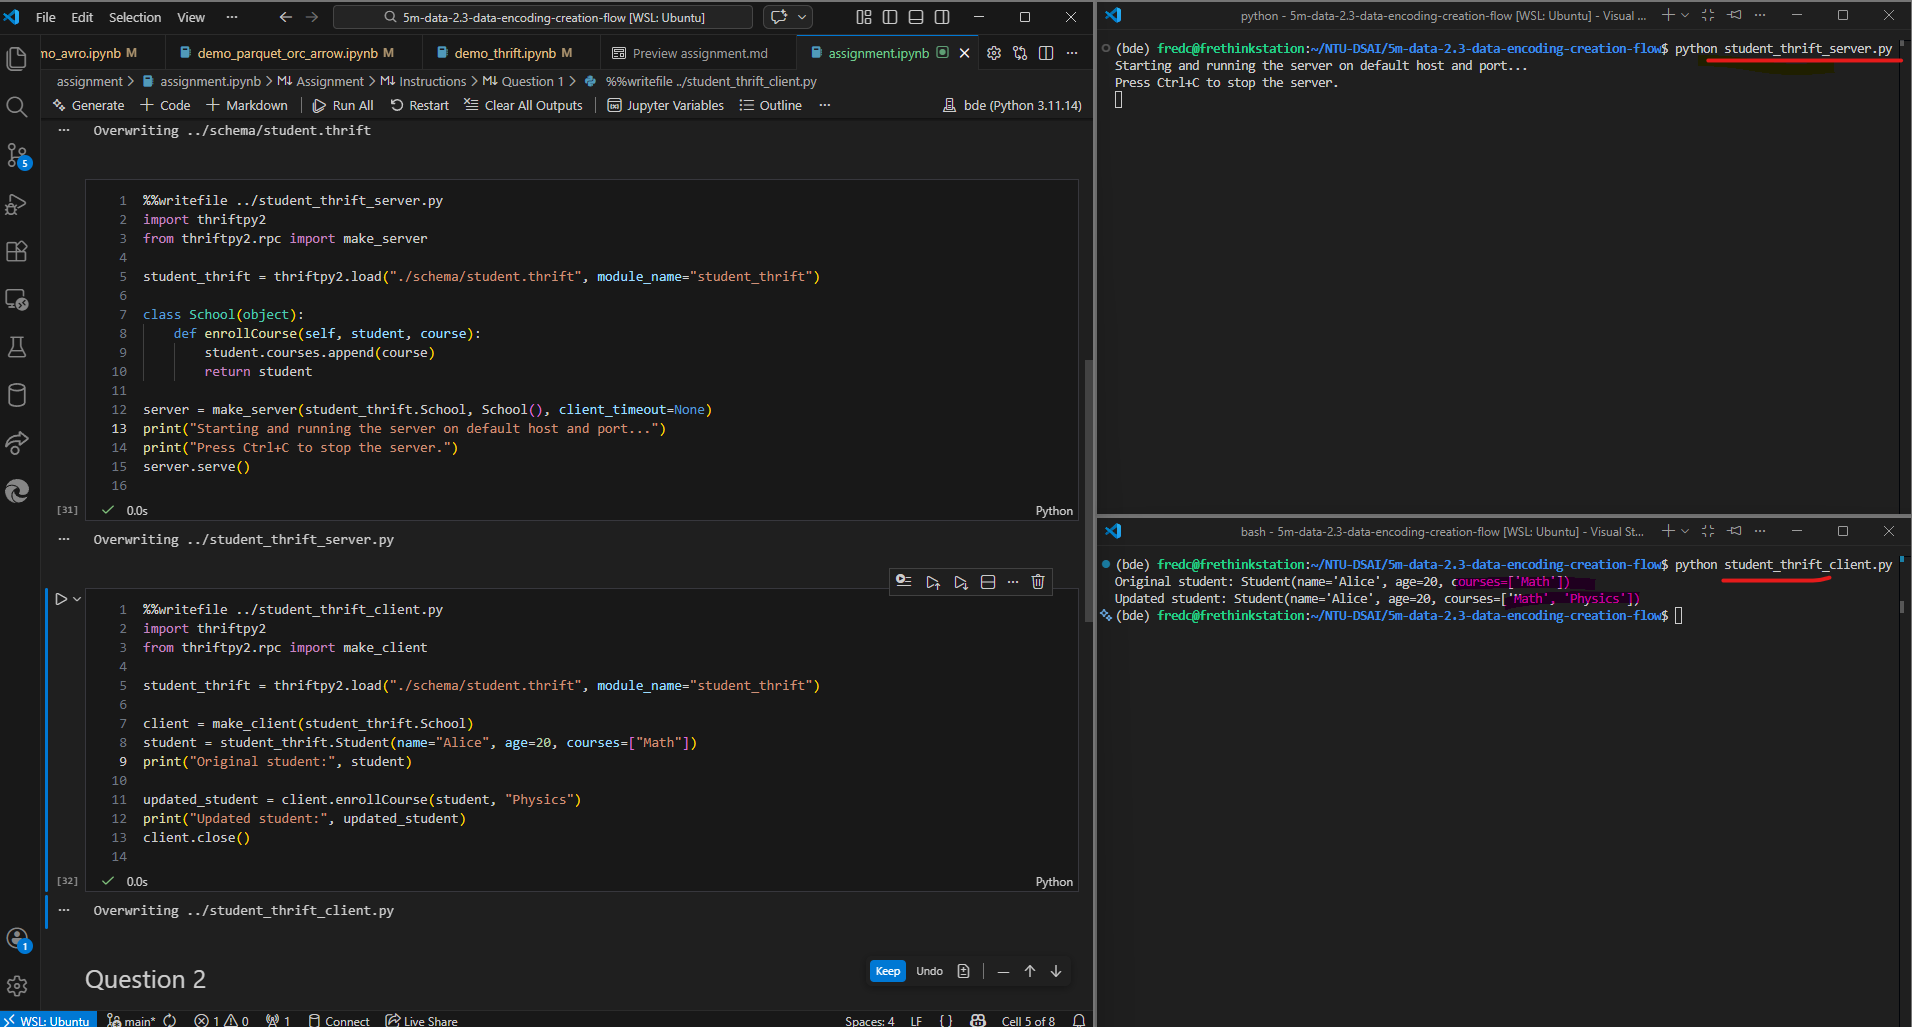

### Question 2

Question: Implement a simple Protocol Buffers server and client that defines a `Book` message with fields `title` (string), `author` (string), and `page_count` (integer). Include a service `Library` with a method `checkoutBook` that takes a `Book` message and returns the same `Book` message.

Answer:

In [33]:
%%writefile ../schema/book.proto

syntax = "proto3";

message Book {
  string title = 1;
  string author = 2;
  int32 page_count = 3;
}

service Library {
  rpc checkoutBook(Book) returns (Book) {}
}

Writing ../schema/book.proto


In [ ]:
python -m grpc_tools.protoc -I./schema --python_out=. --grpc_python_out=. ./schema/book.proto

This will generate the following files:

```bash
book_pb2.py
book_pb2_grpc.py
```

In [43]:
%%writefile ../book_server.py
from concurrent import futures
import grpc
import book_pb2_grpc

# Include a service `Library` with a method `checkoutBook` that 
# takes a `Book` message and returns the same `Book` message.

class Library(book_pb2_grpc.LibraryServicer):
    def checkoutBook(self, request, context):
        print(f"Received book checkout request: {request}")
        return request

server = grpc.server(futures.ThreadPoolExecutor(max_workers=10))
book_pb2_grpc.add_LibraryServicer_to_server(Library(), server)
server.add_insecure_port('[::]:50051')
print("Starting and running the server...")
print("Press Ctrl+C to stop the server.")
server.start()
server.wait_for_termination()



Overwriting ../book_server.py


In [45]:
%%writefile ../book_client.py

import sys
sys.path.append('..')
import grpc
import book_pb2_grpc
import book_pb2

def run():
    with grpc.insecure_channel('localhost:50051') as channel:
        stub = book_pb2_grpc.LibraryStub(channel)
        book = book_pb2.Book(title="The Great Gatsby", author="F. Scott Fitzgerald", page_count=180)
        response = stub.checkoutBook(book)
        print("Checked out book:", response)

with grpc.insecure_channel('localhost:50051') as channel:
    stub = book_pb2_grpc.LibraryStub(channel)
    book = book_pb2.Book(title="The Great Gatsby", author="F. Scott Fitzgerald", page_count=180)
    response = stub.checkoutBook(book)
    print("Checked out book:", response)

Overwriting ../book_client.py


Executing book_server.py and book_client.py

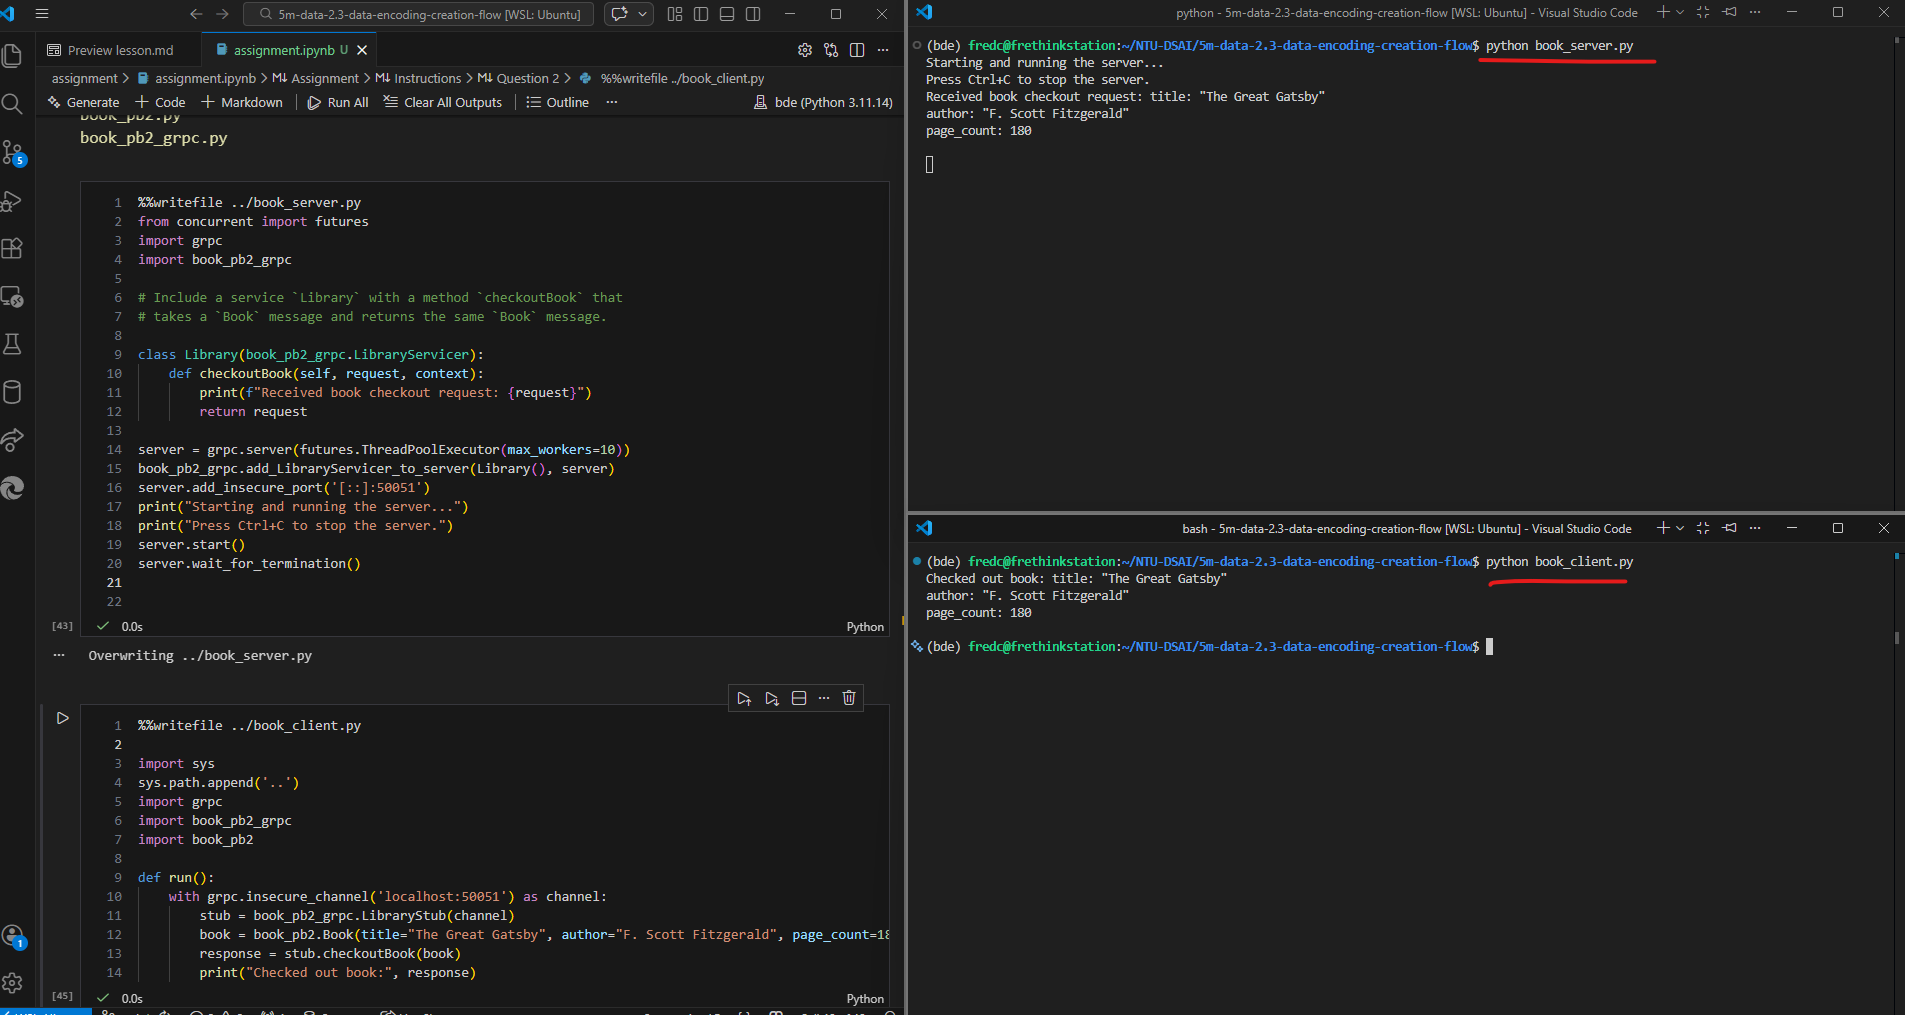

## Submission

- Submit the URL of the GitHub Repository that contains your work to NTU black board.
- Should you reference the work of your classmate(s) or online resources, give them credit by adding either the name of your classmate or URL.